# Chapter 2 — DDPM + DDIM (2-D)

**Theory reference**: `quickguide.tex` Chapter 2.

### Key equations

**Forward marginal** (variance-preserving, Thm 2.1):
$$q(x_t|x_0) = \mathcal{N}(\sqrt{\bar\alpha_t}\,x_0,\,(1-\bar\alpha_t)I)$$

**Tweedie triad** (Thm 2.2): $\varepsilon$, $x_0$, and $v$-predictions are in bijection.

**DDIM update** (η ∈ [0,1] controls stochasticity):
$$x_{t-1} = \sqrt{\bar\alpha_{t-1}}\hat x_0 + \sqrt{1-\bar\alpha_{t-1}-\sigma_\tau^2}\,\varepsilon_\theta(x_t,t) + \sigma_\tau z$$

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cpu


## 1  Noise Schedule Visualization

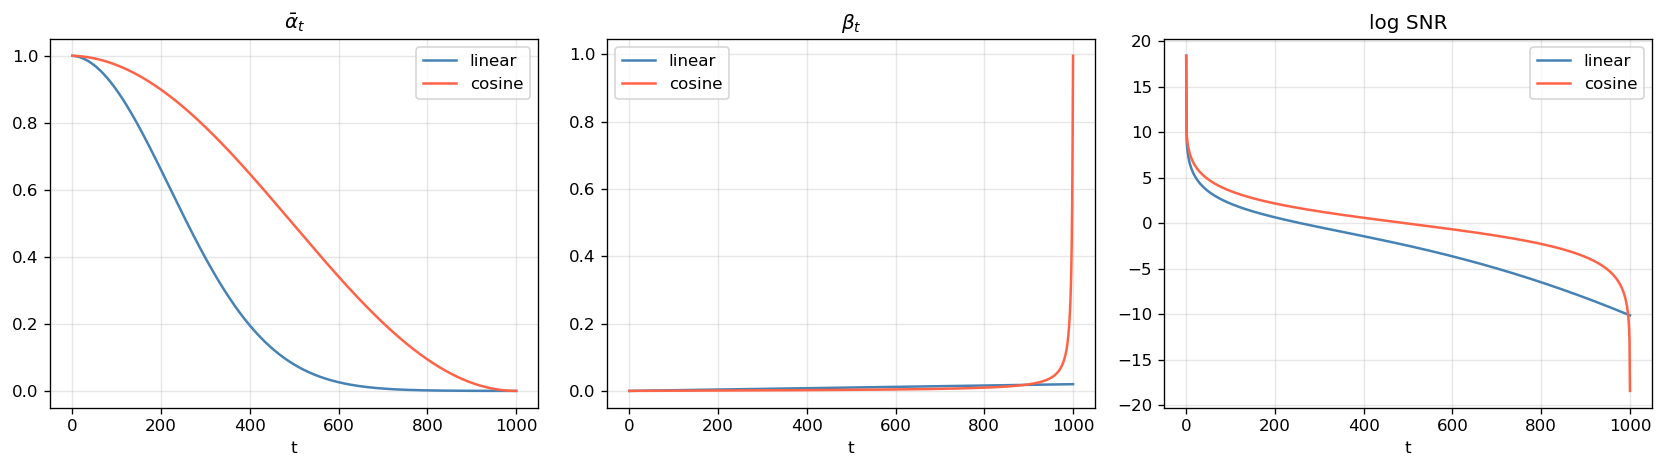

In [2]:
from diffusion_lab.schedulers import linear_vp_schedule, cosine_vp_schedule

sched_lin = linear_vp_schedule(T=1000)
sched_cos = cosine_vp_schedule(T=1000)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

t = np.arange(1001)
for sched, label, c in [(sched_lin, 'linear', 'steelblue'),
                         (sched_cos, 'cosine', 'tomato')]:
    axes[0].plot(t, sched.alpha_bar.numpy(), label=label, c=c)
    axes[1].plot(t, sched.beta.numpy(),      label=label, c=c)
    axes[2].plot(t, sched.log_snr.numpy(),   label=label, c=c)

axes[0].set(title=r'$\bar\alpha_t$', xlabel='t')
axes[1].set(title=r'$\beta_t$',      xlabel='t')
axes[2].set(title='log SNR',          xlabel='t')

for ax in axes:
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2  Forward diffusion chain visualization

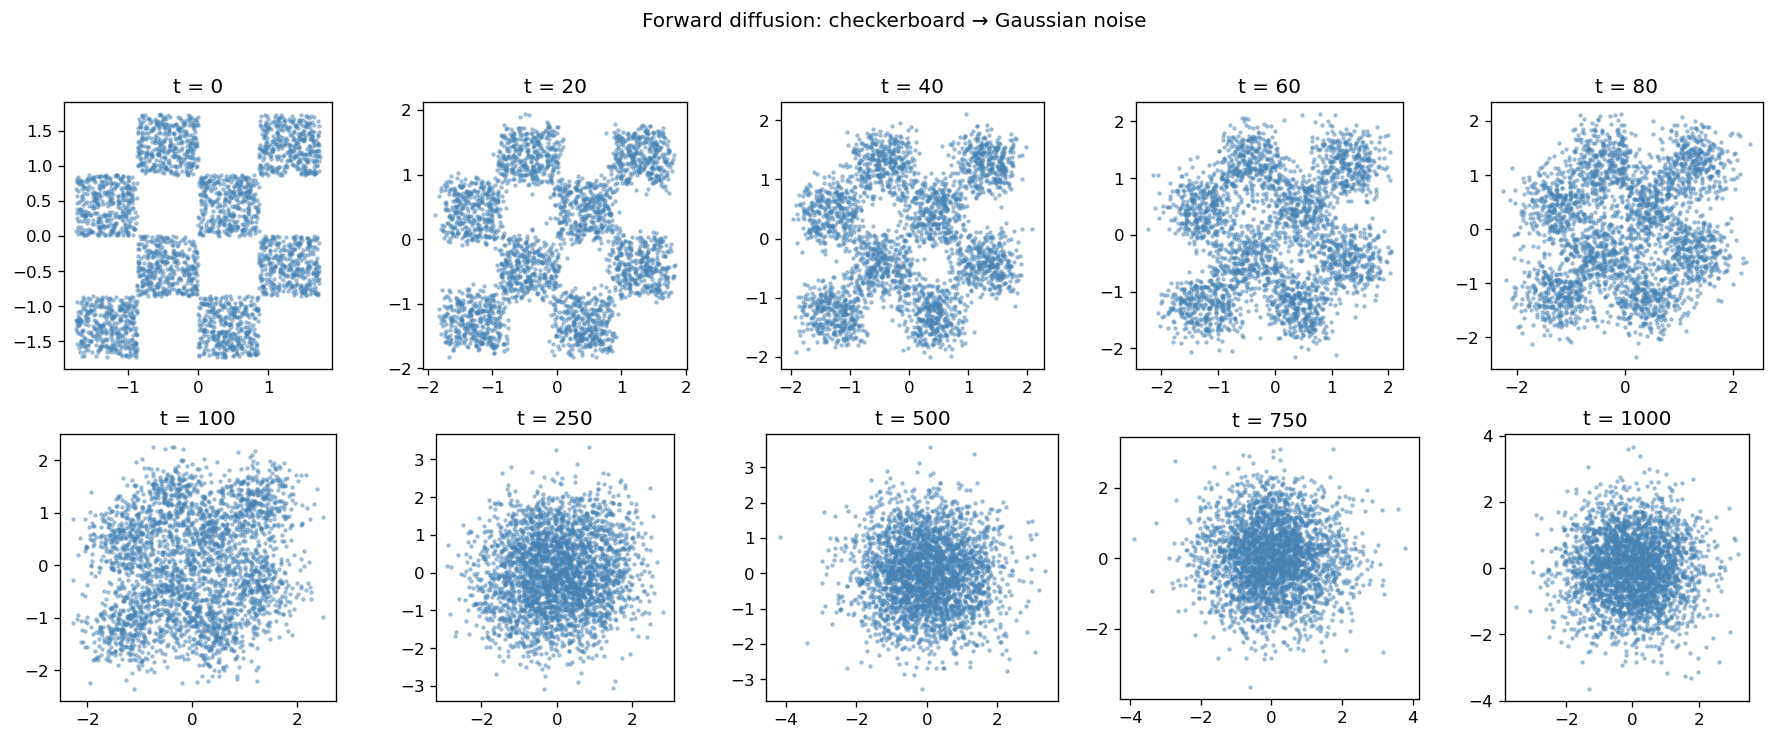

In [3]:
from diffusion_lab.data   import make_dataset
from diffusion_lab.utils  import plot_samples

DATASET = 'checkerboard'
x0_np   = make_dataset(DATASET, n=3000, seed=0)
x0      = torch.from_numpy(x0_np).to(DEVICE)

sched   = linear_vp_schedule(T=1000).to(DEVICE)
t_vals  = [0, 20, 40, 60, 80, 100, 250, 500, 750, 1000]

n_cols = (len(t_vals) + 1) // 2   # ceiling division → works for odd counts too
fig, axes = plt.subplots(2, n_cols, figsize=(3 * n_cols, 6))
axes_flat = axes.flatten()

for ax, t_val in zip(axes_flat, t_vals):
    if t_val == 0:
        xt_np = x0_np
    else:
        t_tensor = torch.full((len(x0),), t_val, dtype=torch.long, device=DEVICE)
        ab  = sched.alpha_bar[t_val].sqrt()
        sig = sched.sigma[t_val]
        xt_np = (ab * x0 + sig * torch.randn_like(x0)).cpu().numpy()
    plot_samples(xt_np, ax=ax, title=f't = {t_val}', s=3, alpha=0.4)

# hide leftover axes if len(t_vals) is odd
for ax in axes_flat[len(t_vals):]:
    ax.set_visible(False)

plt.suptitle('Forward diffusion: checkerboard → Gaussian noise', y=1.02)
plt.tight_layout()
plt.show()

## 3  Model setup and training

In [4]:
from diffusion_lab.data      import get_dataloader
from diffusion_lab.nn        import TimeMLP
from diffusion_lab.models    import DDPM
from diffusion_lab.training  import Trainer
from diffusion_lab.schedulers import cosine_vp_schedule

PREDICTION = 'epsilon'   # ← try 'x0' or 'v'

schedule = cosine_vp_schedule(T=1000).to(DEVICE)
network  = TimeMLP(in_dim=2, out_dim=2, hidden=256, depth=5,
                   time_embed_dim=128).to(DEVICE)
ddpm     = DDPM(network, schedule, prediction=PREDICTION).to(DEVICE)

loader   = get_dataloader(DATASET, n=20_000, batch_size=512,
                          seed=0, device=DEVICE)
trainer  = Trainer(ddpm, loader, lr=3e-4, device=DEVICE, grad_clip=1.0)

print(f'Network params: {sum(p.numel() for p in network.parameters()):,}')

Network params: 231,426


In [5]:
N_STEPS = 10_000
losses  = trainer.train(n_steps=N_STEPS, log_every=1000)
print(f'Initial: {losses[0]:.4f}   Final: {losses[-1]:.4f}')

Training:   0%|          | 0/10000 [00:00<?, ?it/s]

Initial: 0.7329   Final: 0.4562


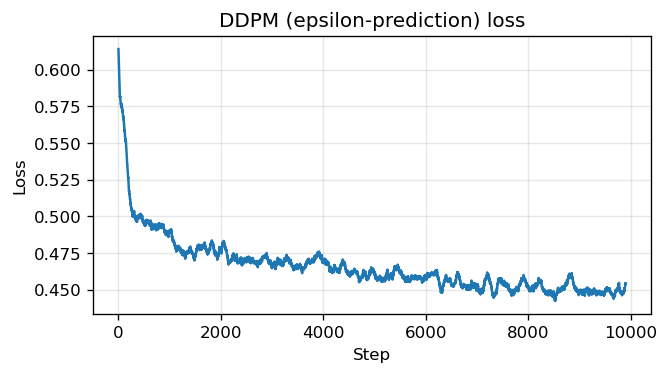

In [6]:
from diffusion_lab.utils import plot_loss_curve
plot_loss_curve(losses, smooth=100, title=f'DDPM ({PREDICTION}-prediction) loss')
plt.show()

## 4  DDPM ancestral sampling (full T=1000 chain)

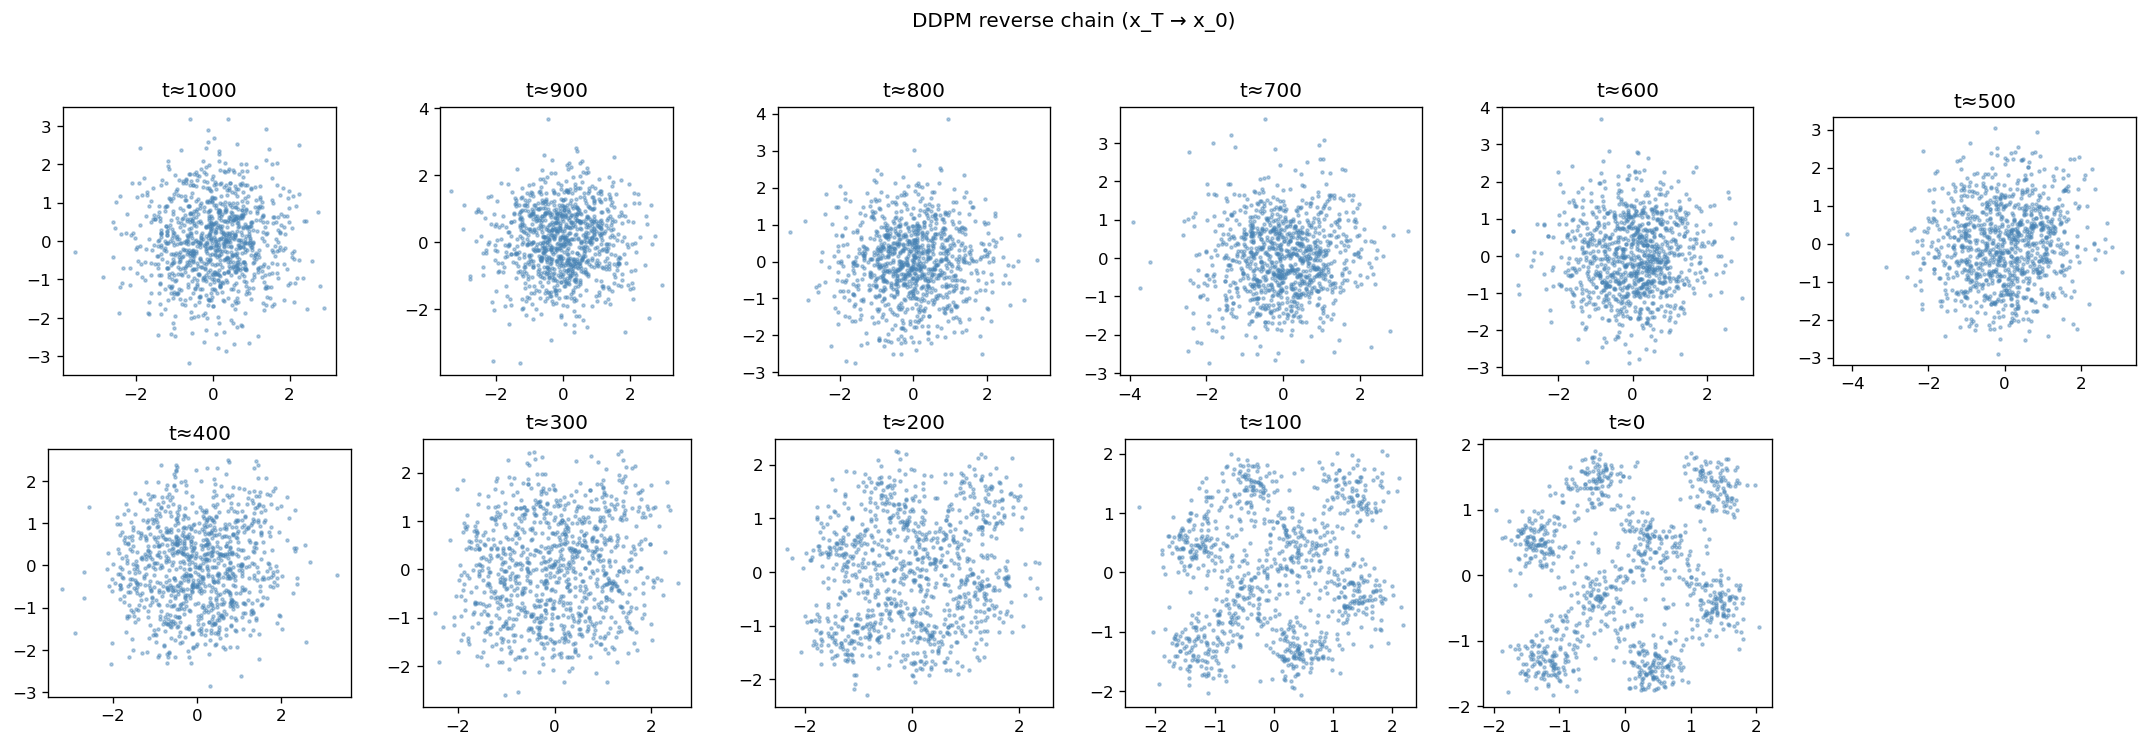

In [8]:
# Full reverse chain — takes a moment (~1000 network calls)
chain = ddpm.sample((1000, 2), device=DEVICE,
                    return_chain=True, chain_stride=100)

# chain[0] = x_T (Gaussian), chain[-1] = x_0 (data)
n      = len(chain)
n_cols = (n + 1) // 2
fig, axes = plt.subplots(2, n_cols, figsize=(3 * n_cols, 6))
axes_flat = axes.flatten()

for ax, frame, i in zip(axes_flat, chain, range(n)):
    plot_samples(frame.numpy(), ax=ax, s=3, alpha=0.4)
    ax.set_title(f't≈{1000 - i * (1000 // (n - 1))}')

for ax in axes_flat[n:]:
    ax.set_visible(False)

plt.suptitle('DDPM reverse chain (x_T → x_0)', y=1.02)
plt.tight_layout()
plt.show()

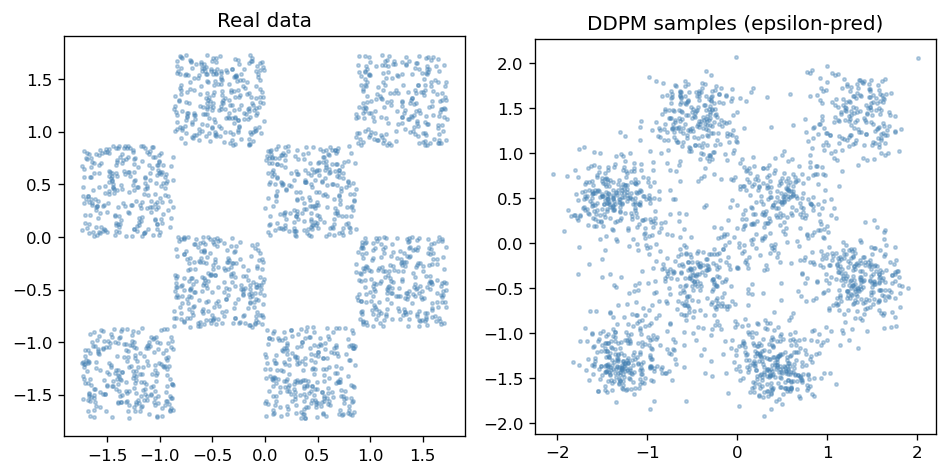

In [9]:
from diffusion_lab.utils import compare_panels

x_gen   = ddpm.sample((2000, 2), device=DEVICE)
compare_panels(x0_np[:2000], x_gen.cpu().numpy(),
               titles=['Real data', f'DDPM samples ({PREDICTION}-pred)'])
plt.show()

## 5  DDIM — accelerated sampling with the same trained network

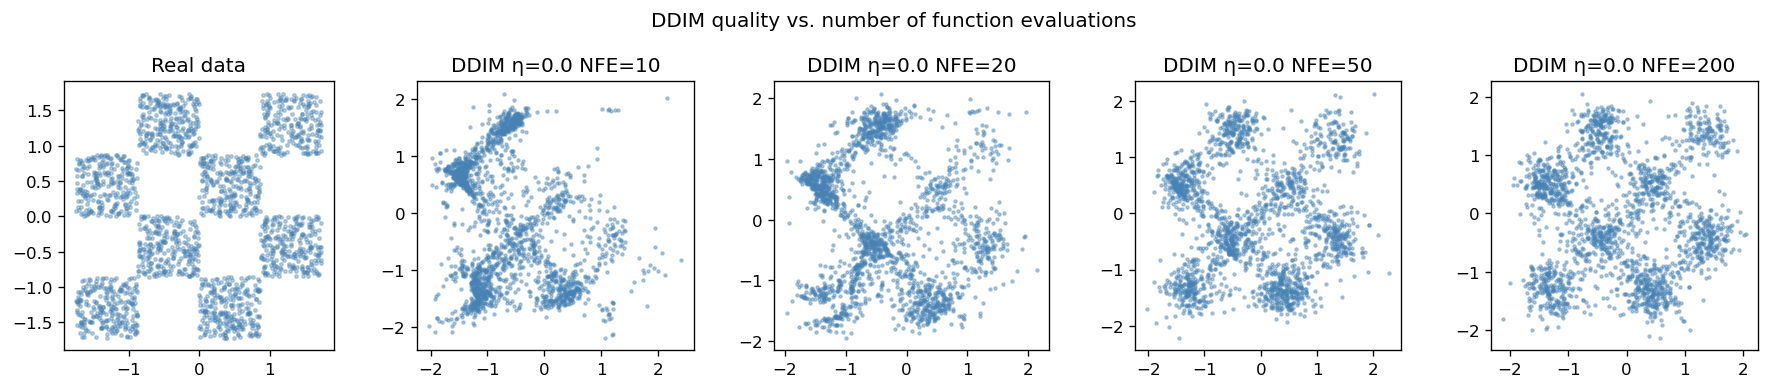

In [10]:
from diffusion_lab.models import DDIMSampler

nfe_vals  = [10, 20, 50, 200]   # number of function evaluations
eta_vals  = [0.0, 0.0, 0.0, 0.0]  # deterministic DDIM (η=0)

fig, axes = plt.subplots(1, len(nfe_vals)+1, figsize=(3*(len(nfe_vals)+1), 3))
plot_samples(x0_np[:2000], ax=axes[0], title='Real data')

for ax, nfe, eta in zip(axes[1:], nfe_vals, eta_vals):
    sampler = DDIMSampler(ddpm, eta=eta, num_steps=nfe)
    x_ddim  = sampler.sample((2000, 2), device=DEVICE)
    plot_samples(x_ddim.cpu().numpy(), ax=ax,
                 title=f'DDIM η={eta} NFE={nfe}', s=3, alpha=0.4)

plt.suptitle('DDIM quality vs. number of function evaluations', y=1.02)
plt.tight_layout()
plt.show()

## 6  Stochasticity ablation: η = 0, 0.5, 1.0

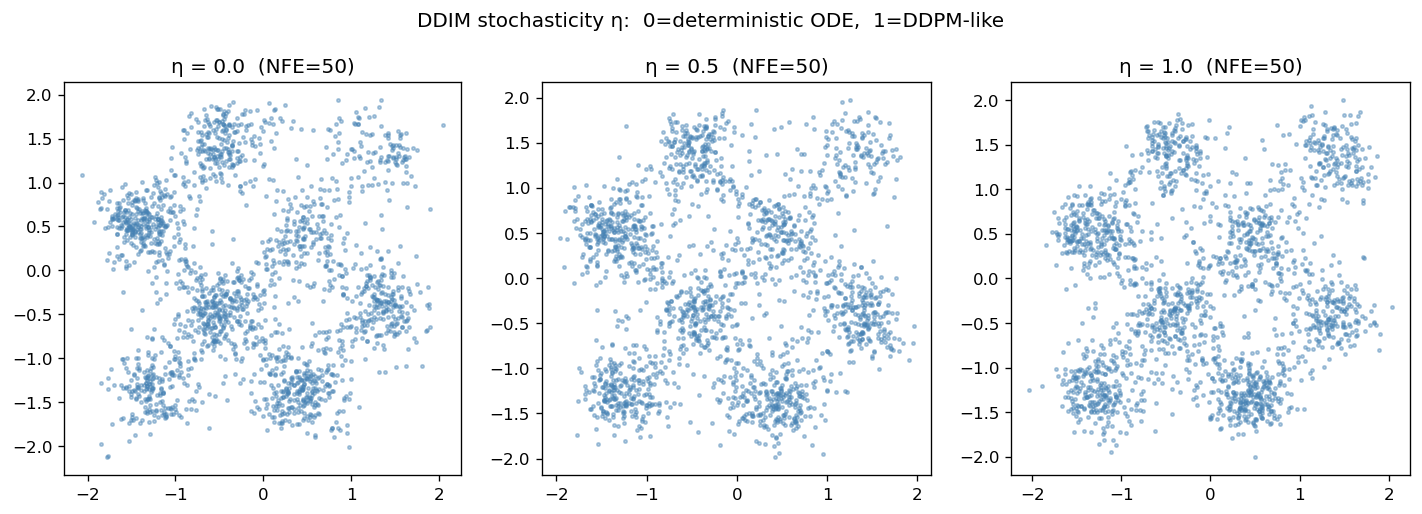

In [11]:
etas = [0.0, 0.5, 1.0]
fig, axes = plt.subplots(1, len(etas), figsize=(4*len(etas), 4))

for ax, eta in zip(axes, etas):
    sampler = DDIMSampler(ddpm, eta=eta, num_steps=50)
    x_s     = sampler.sample((2000, 2), device=DEVICE)
    plot_samples(x_s.cpu().numpy(), ax=ax,
                 title=f'η = {eta}  (NFE=50)', s=4, alpha=0.4)

plt.suptitle('DDIM stochasticity η:  0=deterministic ODE,  1=DDPM-like', y=1.02)
plt.tight_layout()
plt.show()

## 7  Prediction-target ablation: ε vs x₀ vs v

Training:   0%|          | 0/10000 [00:00<?, ?it/s]

epsilon: done


Training:   0%|          | 0/10000 [00:00<?, ?it/s]

x0: done


Training:   0%|          | 0/10000 [00:00<?, ?it/s]

v: done


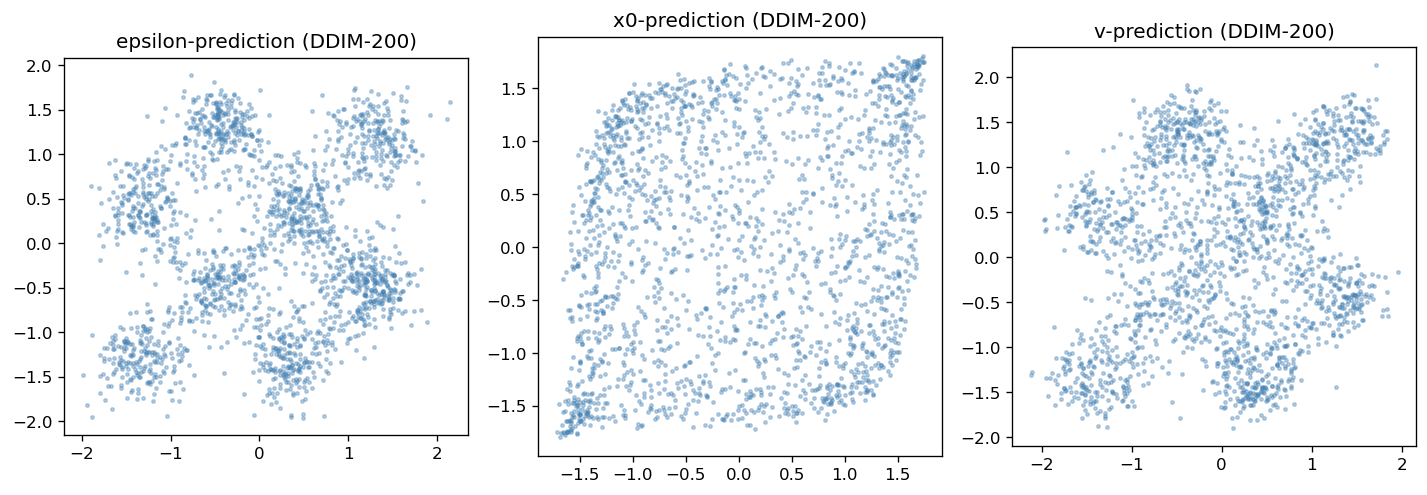

In [14]:
pred_types = ['epsilon', 'x0', 'v']
gen_samples = {}

for pred in pred_types:
    net  = TimeMLP(in_dim=2, out_dim=2, hidden=256, depth=5,
                   time_embed_dim=128).to(DEVICE)
    mdl  = DDPM(net, cosine_vp_schedule(T=1000).to(DEVICE),
                prediction=pred).to(DEVICE)
    tr   = Trainer(mdl, loader, lr=3e-4, device=DEVICE, grad_clip=1.0)
    tr.train(n_steps=10000, log_every=100000)  # quiet
    x_s  = DDIMSampler(mdl, eta=0.0, num_steps=200).sample((2000,2), device=DEVICE)
    gen_samples[pred] = x_s.cpu().numpy()
    print(f'{pred}: done')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, pred in zip(axes, pred_types):
    plot_samples(gen_samples[pred], ax=ax, title=f'{pred}-prediction (DDIM-200)')
plt.tight_layout()
plt.show()